# PSF Modeling Dev

Scratchpad for experimenting with modeling the PSF of the signal trace.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display
from astropy.io import fits
from importlib import reload

import sys
sys.path.append("..")

In [ ]:
path = "../test-data/of9b05010_flt.fits"
# For HST FLT files, science data is typically in extension 1 (SCI)
# and DQ in extension 3.
data = fits.getdata(path, ext=1)
dq = fits.getdata(path, ext=3)

## pick roi

In [ ]:
def _show_roi(img, x_range, y_range, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
    x0, x1 = x_range
    y0, y1 = y_range
    rect = Rectangle(
        (x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", lw=2
    )
    ax.add_patch(rect)
    ax.set_title(f"ROI: y[{y0}:{y1}], x[{x0}:{x1}]")
    plt.show()


def make_roi_widgets(img):
    ny, nx = img.shape
    x_slider = widgets.IntRangeSlider(
        value=[0, max(1, nx // 3)],
        min=0,
        max=nx - 1,
        step=1,
        description="x",
        continuous_update=False,
    )
    y_slider = widgets.IntRangeSlider(
        value=[0, max(1, ny // 3)],
        min=0,
        max=ny - 1,
        step=1,
        description="y",
        continuous_update=False,
    )
    vmin = widgets.FloatText(value=float(np.nanpercentile(img, 5)), description="vmin")
    vmax = widgets.FloatText(value=float(np.nanpercentile(img, 95)), description="vmax")
    return x_slider, y_slider, vmin, vmax


roi_state = {"roi": None}

x_slider, y_slider, vmin_box, vmax_box = make_roi_widgets(np.cbrt(data))


def _update_roi(x, y, vmin, vmax):
    roi_state["roi"] = (y[0], y[1], x[0], x[1])
    _show_roi(data, x, y, vmin=vmin, vmax=vmax)


out = widgets.interactive_output(
    _update_roi,
    {"x": x_slider, "y": y_slider, "vmin": vmin_box, "vmax": vmax_box},
)

display(
    widgets.VBox([x_slider, y_slider, widgets.HBox([vmin_box, vmax_box])]), out
)


In [ ]:
# mask def here
# Define a single horizontal strip mask (y0:y1 across all x)
import ipywidgets as widgets
from IPython.display import display

roi = roi_state["roi"]
(y0, y1, x0, x1) = roi
roi_data = data[y0:y1, x0:x1]

roi_mask_strip = np.zeros(roi_data.shape, dtype=bool)

strip_range = widgets.IntRangeSlider(
    value=[0, max(1, roi_data.shape[0] // 3)],
    min=0,
    max=roi_data.shape[0] - 1,
    step=1,
    description="y strip",
    continuous_update=False,
    layout=widgets.Layout(width='500px'),  # Make the slider longer
)
strip_out = widgets.Output()


def _render_strip(y_strip):
    strip_out.clear_output()
    with strip_out:
        fig, ax = plt.subplots(1, 1, figsize=(7, 6))
        ax.imshow(np.cbrt(roi_data), origin="lower", aspect="auto")
        y0, y1 = y_strip
        rect = Rectangle((0, y0), roi_data.shape[1], y1 - y0, fill=False, edgecolor="yellow", lw=2)
        ax.add_patch(rect)
        ax.set_title("ROI with horizontal strip")
        plt.tight_layout()

strip_out_widget = widgets.interactive_output(_render_strip, {"y_strip": strip_range})
_display_strip = widgets.VBox([strip_range, strip_out_widget])

# Update strip mask
_y0, _y1 = strip_range.value
roi_mask_strip[_y0:_y1, :] = True

print("Masked pixels (strip):", int(np.sum(roi_mask_strip)))

display(_display_strip)


In [ ]:
# The current ROI selection (y0, y1, x0, x1):
print(roi_state["roi"])
print(strip_range.value)


## set roi and trace mask

In [24]:
# fix ROI for future use
roi = (123, 265, 282, 522)
strip_range = (117, 133)

(y0, y1, x0, x1) = roi
roi_data = data[y0:y1, x0:x1]
_y0, _y1 = strip_range
roi_mask_strip[_y0:_y1, :] = True
roi_mask_strip = np.zeros(roi_data.shape, dtype=bool)

## try steamrolling over trace see what happens

In [ ]:
# # Define a narrower x-window around the airglow line (100 pixels)
# # Compute row centroids within ROI and take the median
# roi_rows = data[y0:y1, x0:x1]
# x_roi = np.arange(x0, x1)
# row_centroids = []
# for row in roi_rows:
#     row = np.clip(row, 0.0, None)
#     if np.sum(row) > 0:
#         row_centroids.append(np.sum(x_roi * row) / np.sum(row))

# center_x = int(np.median(row_centroids))
# window_half = 50
# x0_narrow = max(x0, center_x - window_half)
# x1_narrow = min(x1, center_x + window_half)

# print("Narrow window:", (x0_narrow, x1_narrow))

In [ ]:
# # Iterative airglow fitting over ROI rows
# from importlib import reload
# import models
# reload(models)

# # user controls
# n_iters = 3

# # ROI slices
# (y0, y1, x0, x1) = roi
# roi_data = data[y0:y1, x0:x1]
# rows = data[y0:y1]
# row_indices = np.arange(y0, y1)

# # DQ mask for fits
# if dq is not None:
#     dq_rows = dq[y0:y1]
# else:
#     dq_rows = None

# DQ_FLAGS = [1, 2, 4, 16, 32, 256, 512, 8192]
# dq_mask_value = int(np.sum(DQ_FLAGS))

# x_grid = np.arange(data.shape[1])
# init = None

# for _ in range(n_iters):
#     fit_results = models.fit_airglow_rows(
#         rows,
#         x_grid,
#         x0_narrow,
#         x1_narrow,
#         row_indices=row_indices,
#         dq_rows=dq_rows,
#         dq_mask_value=dq_mask_value,
#         lsf_kernel=None,
#         init=init,
#         minimize_options={"maxiter": 10000, "xatol": 1e-10, "fatol": 1e-10}
#     )
#     init = fit_results["params"]


In [ ]:

# # Only analyze and plot the narrow window
# # Extract the narrow slices for plotting
# narrow_slice = slice(x0_narrow - x0, x1_narrow - x0)
# roi_data_narrow = roi_data[:, narrow_slice]
# roi_fit_narrow = fit_results["fits"]  # already shape (y, x_narrow)
# residual_narrow = roi_data_narrow - roi_fit_narrow
# mean_residual_narrow = np.nanmean(residual_narrow, axis=0)
# x_narrow = np.arange(x0_narrow, x1_narrow)

# fig, axes = plt.subplots(1, 3, figsize=(6, 2), sharex=True, sharey=True)
# for ax, img, title in zip(
#     axes,
#     [roi_data_narrow, roi_fit_narrow, residual_narrow],
#     ["ROI data (narrow)", "Airglow fit (narrow)", "Residual (narrow)"],
# ):
#     ax.imshow(np.cbrt(img), origin="lower", aspect="auto")
#     ax.set_title(title)
# plt.tight_layout()

# fig, ax = plt.subplots(1, 1, figsize=(4, 2.5))
# ax.plot(x_narrow, mean_residual_narrow)
# ax.set_title("Mean residual across narrow window")
# ax.set_xlabel("x (narrow)")
# ax.set_ylabel("mean residual")
# plt.tight_layout()

### result
that didn't really work. going to try fitting just a smaller range with the airglow masked. not sure why the fits above start to get so biased with increasing row. 

## trying smaller roi

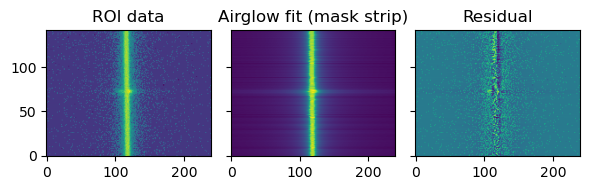

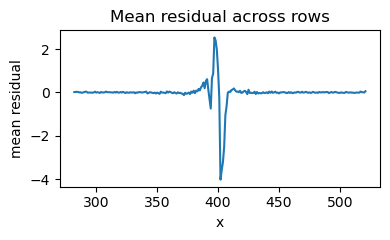

In [25]:
# Fit airglow rows excluding the horizontal strip mask
from importlib import reload
import models
reload(models)

n_iters = 3

(y0, y1, x0, x1) = roi
roi_data = data[y0:y1, x0:x1]
rows = data[y0:y1]
row_indices = np.arange(y0, y1)

if dq is not None:
    dq_rows = dq[y0:y1]
else:
    dq_rows = None

DQ_FLAGS = [1, 2, 4, 16, 32, 256, 512, 8192]
dq_mask_value = int(np.sum(DQ_FLAGS))

# Exclude strip rows from fitting
rows_fit = rows.copy()
if "roi_mask_strip" in globals():
    strip_mask_full = np.zeros_like(rows_fit, dtype=bool)
    strip_mask_full[:, x0:x1] = roi_mask_strip
    rows_fit[strip_mask_full] = np.nan

x_grid = np.arange(data.shape[1])
init = None

for _ in range(n_iters):
    fit_results = models.fit_airglow_rows(
        rows_fit,
        x_grid,
        x0,
        x1,
        row_indices=row_indices,
        dq_rows=dq_rows,
        dq_mask_value=dq_mask_value,
        lsf_kernel=None,
        init=init,
    )
    init = fit_results["params"]

roi_fit = np.zeros_like(roi_data)
roi_fit[:, x0 - x0 : x1 - x0] = fit_results["fits"]
residual = roi_data - roi_fit
mean_residual = np.nanmean(residual, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(6, 2), sharex=True, sharey=True)
for ax, img, title in zip(
    axes,
    [roi_data, roi_fit, residual],
    ["ROI data", "Airglow fit (mask strip)", "Residual"],
):
    ax.imshow(np.cbrt(img), origin="lower", aspect="auto")
    ax.set_title(title)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(4, 2.5))
ax.plot(np.arange(x0, x1), mean_residual)
ax.set_title("Mean residual across rows")
ax.set_xlabel("x")
ax.set_ylabel("mean residual")
plt.tight_layout()